# Load HCP parcellated task data
## (version with Behavioural Data)

The HCP dataset comprises task-based fMRI from a large sample of human subjects. The NMA-curated dataset includes time series data that has been preprocessed and spatially-downsampled by aggregating within 360 regions of interest.

In order to use this dataset, please electronically sign the HCP data use terms at [ConnectomeDB](https://db.humanconnectome.org). Instructions for this are on pp. 24-25 of the [HCP Reference Manual](https://www.humanconnectome.org/storage/app/media/documentation/s1200/HCP_S1200_Release_Reference_Manual.pdf).

In this notebook, NMA provides code for downloading the data and doing some basic visualisation and processing.

In [56]:
# @title Install dependencies
!pip install nilearn --quiet

In [57]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [58]:
#@title Figure settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/course-content/main/nma.mplstyle")

In [59]:
# The data shared for NMA projects is a subset of the full HCP dataset
N_SUBJECTS = 100

# The data have already been aggregated into ROIs from the Glasser parcellation
N_PARCELS = 360

# The acquisition parameters for all tasks were identical
TR = 0.72  # Time resolution, in seconds

# The parcels are matched across hemispheres with the same order
HEMIS = ["Right", "Left"]

# Each experiment was repeated twice in each subject
RUNS   = ['LR','RL']
N_RUNS = 2

# There are 7 tasks. Each has a number of 'conditions'
# TIP: look inside the data folders for more fine-graned conditions

EXPERIMENTS = {
    'MOTOR'      : {'cond':['lf','rf','lh','rh','t','cue']},
    'WM'         : {'cond':['0bk_body','0bk_faces','0bk_places','0bk_tools','2bk_body','2bk_faces','2bk_places','2bk_tools']},
    'EMOTION'    : {'cond':['fear','neut']},
    'GAMBLING'   : {'cond':['loss','win']},
    'LANGUAGE'   : {'cond':['math','story']},
    'RELATIONAL' : {'cond':['match','relation']},
    'SOCIAL'     : {'cond':['ment','rnd']}
}

> For a detailed description of the tasks have a look pages 45-54 of the [HCP reference manual](https://www.humanconnectome.org/storage/app/media/documentation/s1200/HCP_S1200_Release_Reference_Manual.pdf).

# Downloading data

The task data are shared in different files, but they will unpack into the same directory structure.


In [60]:
# @title Download data file
import os, requests

fname = "hcp_task.tgz"
url = "https://osf.io/2y3fw/download"

if not os.path.isfile(fname):
  try:
    r = requests.get(url)
  except requests.ConnectionError:
    print("!!! Failed to download data !!!")
  else:
    if r.status_code != requests.codes.ok:
      print("!!! Failed to download data !!!")
    else:
      with open(fname, "wb") as fid:
        fid.write(r.content)

In [61]:
# The download cells will store the data in nested directories starting here:
HCP_DIR = "./hcp_task"

# importing the "tarfile" module
import tarfile

# open file
with tarfile.open(fname) as tfile:
  # extracting file
  tfile.extractall('.')

subjects = np.loadtxt(os.path.join(HCP_DIR, 'subjects_list.txt'), dtype='str')

/tmp/ipykernel_917/2825554391.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tfile.extractall('.')


## Understanding the folder organisation

The data folder has the following organisation:

- hcp
  - regions.npy (information on the brain parcellation)
  - subjects_list.txt (list of subject IDs)
  - subjects (main data folder)
    - [subjectID] (subject-specific subfolder)
      - EXPERIMENT (one folder per experiment)
        - RUN (one folder per run)
          - data.npy (the parcellated time series data)
          - EVs (EVs folder)
            - [ev1.txt] (one file per condition)
            - [ev2.txt]
            - Stats.txt (behavioural data [where available] - averaged per run)
            - Sync.txt (ignore this file)



## Loading region information

Downloading this dataset will create the `regions.npy` file, which contains the region name and network assignment for each parcel.

Detailed information about the name used for each region is provided [in the Supplement](https://static-content.springer.com/esm/art%3A10.1038%2Fnature18933/MediaObjects/41586_2016_BFnature18933_MOESM330_ESM.pdf) to [Glasser et al. 2016](https://www.nature.com/articles/nature18933).

Information about the network parcellation is provided in [Ji et al, 2019](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6289683/).



In [62]:
regions = np.load(f"{HCP_DIR}/regions.npy").T
region_info = dict(
    name=regions[0].tolist(),
    network=regions[1],
    hemi=['Right']*int(N_PARCELS/2) + ['Left']*int(N_PARCELS/2),
)

In [63]:
print(region_info)

{'name': ['R_V1', 'R_MST', 'R_V6', 'R_V2', 'R_V3', 'R_V4', 'R_V8', 'R_4', 'R_3b', 'R_FEF', 'R_PEF', 'R_55b', 'R_V3A', 'R_RSC', 'R_POS2', 'R_V7', 'R_IPS1', 'R_FFC', 'R_V3B', 'R_LO1', 'R_LO2', 'R_PIT', 'R_MT', 'R_A1', 'R_PSL', 'R_SFL', 'R_PCV', 'R_STV', 'R_7Pm', 'R_7m', 'R_POS1', 'R_23d', 'R_v23ab', 'R_d23ab', 'R_31pv', 'R_5m', 'R_5mv', 'R_23c', 'R_5L', 'R_24dd', 'R_24dv', 'R_7AL', 'R_SCEF', 'R_6ma', 'R_7Am', 'R_7PL', 'R_7PC', 'R_LIPv', 'R_VIP', 'R_MIP', 'R_1', 'R_2', 'R_3a', 'R_6d', 'R_6mp', 'R_6v', 'R_p24pr', 'R_33pr', 'R_a24pr', 'R_p32pr', 'R_a24', 'R_d32', 'R_8BM', 'R_p32', 'R_10r', 'R_47m', 'R_8Av', 'R_8Ad', 'R_9m', 'R_8BL', 'R_9p', 'R_10d', 'R_8C', 'R_44', 'R_45', 'R_47l', 'R_a47r', 'R_6r', 'R_IFJa', 'R_IFJp', 'R_IFSp', 'R_IFSa', 'R_p9-46v', 'R_46', 'R_a9-46v', 'R_9-46d', 'R_9a', 'R_10v', 'R_a10p', 'R_10pp', 'R_11l', 'R_13l', 'R_OFC', 'R_47s', 'R_LIPd', 'R_6a', 'R_i6-8', 'R_s6-8', 'R_43', 'R_OP4', 'R_OP1', 'R_OP2-3', 'R_52', 'R_RI', 'R_PFcm', 'R_PoI2', 'R_TA2', 'R_FOP4', 'R_MI', 'R

In [64]:
reg_df = pd.DataFrame(region_info)
print(reg_df)
reg_df.to_csv('hcp_task/region_info.csv')

        name       network   hemi
0       R_V1       Visual1  Right
1      R_MST       Visual2  Right
2       R_V6       Visual2  Right
3       R_V2       Visual2  Right
4       R_V3       Visual2  Right
..       ...           ...    ...
355  L_STSva  Posterior-Mu   Left
356   L_TE1m  Frontopariet   Left
357     L_PI  Cingulo-Oper   Left
358  L_a32pr  Cingulo-Oper   Left
359    L_p24  Cingulo-Oper   Left

[360 rows x 3 columns]


# Help functions

We provide two helper functions: one for loading the time series from a single suject and a single run, and one for loading an EV file for each task.

An EV file (EV:Explanatory Variable) describes the task experiment in terms of stimulus onset, duration, and amplitude. These can be used to model the task time series data.

In [65]:
def load_single_timeseries(subject, experiment, run, remove_mean=True):
  """Load timeseries data for a single subject and single run.

  Args:
    subject (str):      subject ID to load
    experiment (str):   Name of experiment
    run (int):          (0 or 1)
    remove_mean (bool): If True, subtract the parcel-wise mean (typically the mean BOLD signal is not of interest)

  Returns
    ts (n_parcel x n_timepoint array): Array of BOLD data values

  """
  bold_run  = RUNS[run]
  bold_path = f"{HCP_DIR}/subjects/{subject}/{experiment}/tfMRI_{experiment}_{bold_run}"
  bold_file = "data.npy"
  ts = np.load(f"{bold_path}/{bold_file}")
  if remove_mean:
    ts -= ts.mean(axis=1, keepdims=True)
  return ts


def load_evs(subject, experiment, run):
  """Load EVs (explanatory variables) data for one task experiment.

  Args:
    subject (str): subject ID to load
    experiment (str) : Name of experiment
    run (int): 0 or 1

  Returns
    evs (list of lists): A list of frames associated with each condition

  """
  frames_list = []
  task_key = f'tfMRI_{experiment}_{RUNS[run]}'
  for cond in EXPERIMENTS[experiment]['cond']:
    ev_file  = f"{HCP_DIR}/subjects/{subject}/{experiment}/{task_key}/EVs/{cond}.txt"
    ev_array = np.loadtxt(ev_file, ndmin=2, unpack=True)
    ev       = dict(zip(["onset", "duration", "amplitude"], ev_array))
    # Determine when trial starts, rounded down
    start = np.floor(ev["onset"] / TR).astype(int)
    # Use trial duration to determine how many frames to include for trial
    duration = np.ceil(ev["duration"] / TR).astype(int)
    # Take the range of frames that correspond to this specific trial
    frames = [s + np.arange(0, d) for s, d in zip(start, duration)]
    frames_list.append(frames)

  return frames_list

# Example run

Let's load the timeseries data for the MOTOR experiment from a single subject and a single run

In [66]:
my_exp = 'MOTOR'
my_subj = subjects[1]
my_run = 1

data = load_single_timeseries(subject=my_subj,
                              experiment=my_exp,
                              run=my_run,
                              remove_mean=True)
print(data.shape)

(360, 284)


As you can see the time series data contains 284 time points in 360 regions of interest (ROIs).



Now in order to understand how to model these data, we need to relate the time series to the experimental manipulation. This is described by the EV files. Let us load the EVs for this experiment.

In [67]:
evs = load_evs(subject=my_subj, experiment=my_exp, run=my_run)

For the motor task, this evs variable contains a list of 5 arrays corresponding to the 5 conditions.

Now let's use these evs to compare the average activity during the left foot ('lf') and right foot ('rf') conditions:

In [68]:
# we need a little function that averages all frames from any given condition
def average_frames(data, evs, experiment, cond):
  idx = EXPERIMENTS[experiment]['cond'].index(cond)
  return np.mean(np.concatenate([np.mean(data[:, evs[idx][i]], axis=1, keepdims=True) for i in range(len(evs[idx]))], axis=-1), axis=1)


lf_activity = average_frames(data, evs, my_exp, 'lf')
rf_activity = average_frames(data, evs, my_exp, 'rf')
contrast = lf_activity - rf_activity  # difference between left and right hand movement

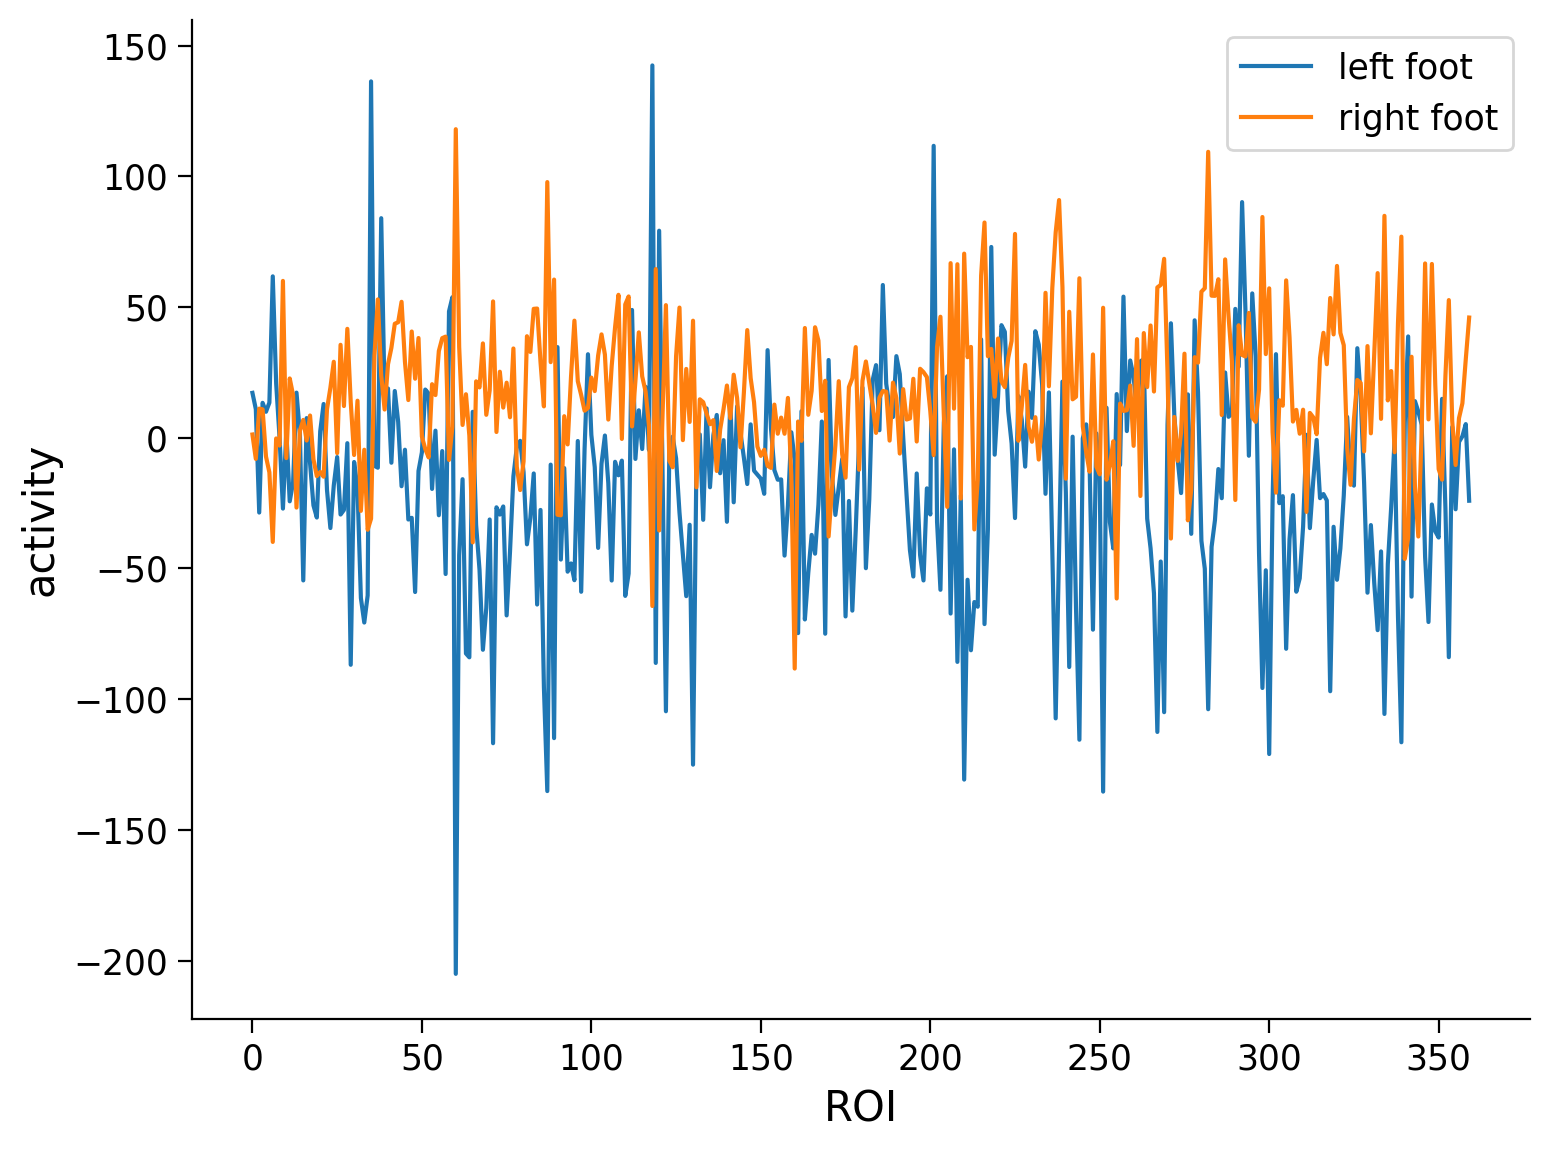

In [69]:
# Plot activity level in each ROI for both conditions
plt.plot(lf_activity,label='left foot')
plt.plot(rf_activity,label='right foot')
plt.xlabel('ROI')
plt.ylabel('activity')
plt.legend()
plt.show()

Now let's plot these activity vectors. We will also make use of the ROI names to find out which brain areas show highest activity in these conditions. But since there are so many areas, we will group them by network.

A powerful tool for organising and plotting this data is the combination of pandas and seaborn. Below is an example where we use pandas to create a table for the activity data and we use seaborn oto visualise it.





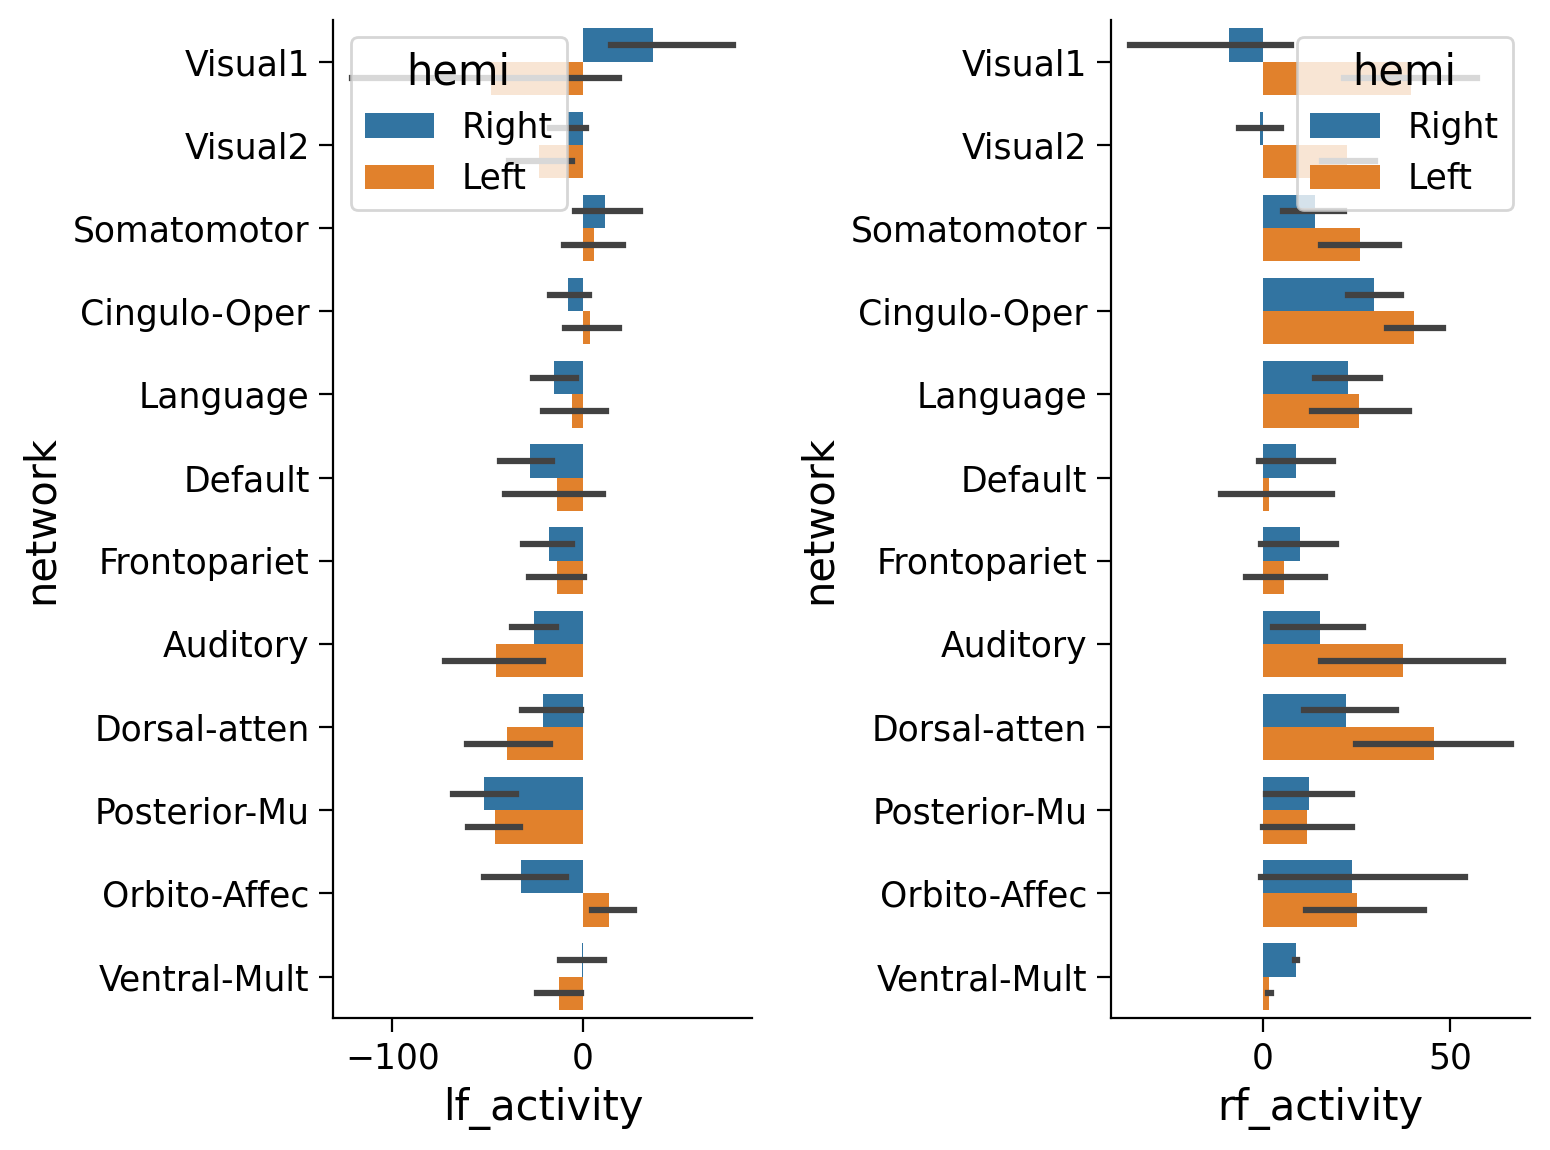

In [70]:
df = pd.DataFrame({'lf_activity' : lf_activity,
                   'rf_activity' : rf_activity,
                   'network' : region_info['network'],
                   'hemi' : region_info['hemi']})

fig, (ax1, ax2) = plt.subplots(1, 2)
sns.barplot(y='network', x='lf_activity', data=df, hue='hemi',ax=ax1)
sns.barplot(y='network', x='rf_activity', data=df, hue='hemi',ax=ax2)
plt.show()

You should be able to notice that for the somatosensory network, brain activity in the right hemi is higher for the left foot movement and vice versa for the left hemi and right foot. But this may be subtle at the single subject/session level (these are quick 3-4min scans).


Let us boost thee stats by averaging across all subjects and runs.

In [71]:
group_contrast = 0
for s in subjects:
  for r in [0, 1]:
    data = load_single_timeseries(subject=s, experiment=my_exp,
                                  run=r, remove_mean=True)
    evs = load_evs(subject=s, experiment=my_exp,run=r)

    lf_activity = average_frames(data, evs, my_exp, 'lf')
    rf_activity = average_frames(data, evs, my_exp, 'rf')

    contrast = lf_activity - rf_activity
    group_contrast += contrast

group_contrast /= (len(subjects)*2)  # remember: 2 sessions per subject

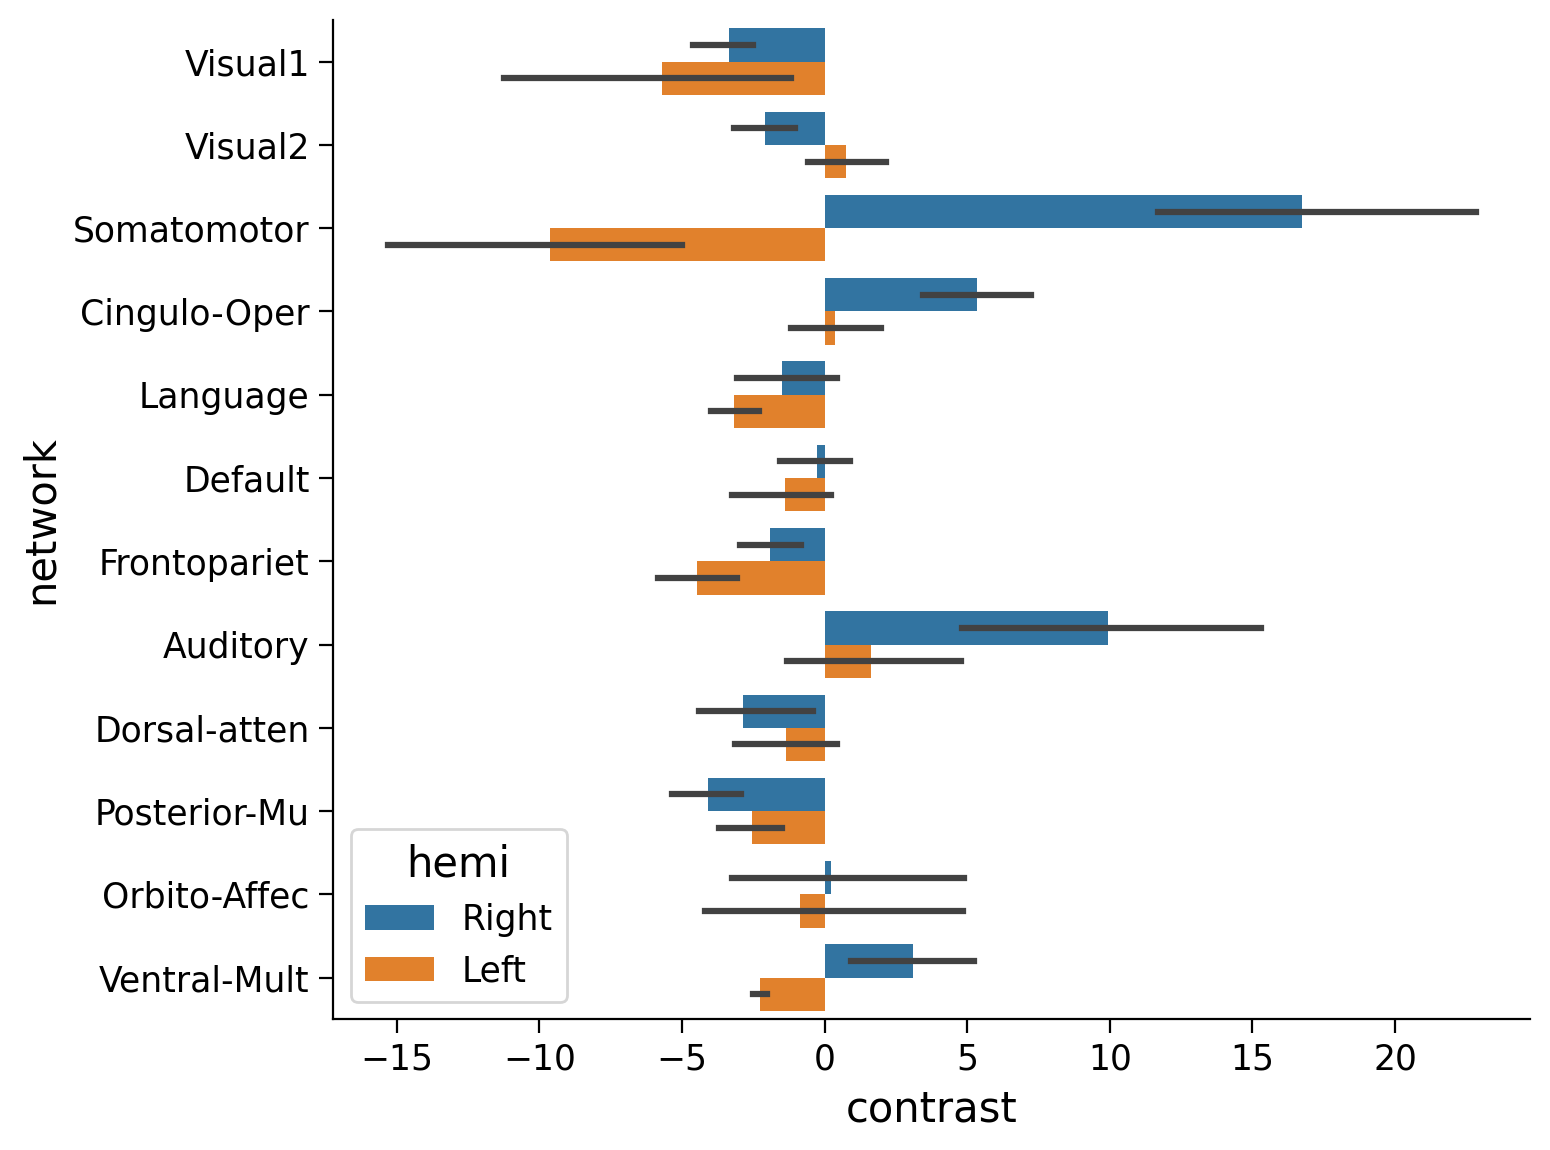

In [72]:
df = pd.DataFrame({'contrast' : group_contrast,
                   'network' : region_info['network'],
                   'hemi' : region_info['hemi']
                   })
# we will plot the left foot minus right foot contrast so we only need one plot
plt.figure()
sns.barplot(y='network', x='contrast', data=df, hue='hemi')
plt.show()

# Visualising the results on a brain

Finally, we will visualise these results on the cortical surface of an average brain.

In [73]:
# @title NMA provides an atlas. Run this cell to download it
import os, requests

# NMA provides an atlas
fname = f"{HCP_DIR}/atlas.npz"
url = "https://osf.io/j5kuc/download"

if not os.path.isfile(fname):
  try:
    r = requests.get(url)
  except requests.ConnectionError:
    print("!!! Failed to download data !!!")
  else:
    if r.status_code != requests.codes.ok:
      print("!!! Failed to download data !!!")
    else:
      with open(fname, "wb") as fid:
        fid.write(r.content)

with np.load(fname) as dobj:
  atlas = dict(**dobj)

In [74]:
# This uses the nilearn package
from nilearn import plotting, datasets

# Try both hemispheres (L->R and left->right)
fsaverage = datasets.fetch_surf_fsaverage()
surf_contrast = group_contrast[atlas["labels_L"]]
plotting.view_surf(fsaverage['infl_left'],
                   surf_contrast,
                   vmax=20)

In [75]:
my_subj = subjects[0]
my_exp = 'WM'
my_run = 0


data = load_single_timeseries(subject=my_subj, experiment=my_exp, run=my_run, remove_mean=True)
print(f"Full run data shape: {data.shape} (Should be 360 regions x 405 Timepoints)")


evs = load_evs(subject=my_subj, experiment=my_exp, run=my_run)

def get_task_frames(evs, experiment, condition_prefix):
    frames = []
    for i, cond in enumerate(EXPERIMENTS[experiment]['cond']):
        if cond.startswith(condition_prefix):
            for trial_frames in evs[i]:
                frames.extend(trial_frames)
    return np.unique(frames)

frames_0bk = get_task_frames(evs, my_exp, '0bk')
frames_2bk = get_task_frames(evs, my_exp, '2bk')

frames_0bk = frames_0bk[frames_0bk < data.shape[1]].astype(int)
frames_2bk = frames_2bk[frames_2bk < data.shape[1]].astype(int)

print(f"Number of 0-back frames identified: {len(frames_0bk)}")
print(f"Number of 2-back frames identified: {len(frames_2bk)}")

ts_0bk = data[:, frames_0bk]
ts_2bk = data[:, frames_2bk]

print(f"Final 0-back data shape: {ts_0bk.shape}")
print(f"Final 2-back data shape: {ts_2bk.shape}")

Full run data shape: (360, 405) (Should be 360 regions x 405 Timepoints)
Number of 0-back frames identified: 156
Number of 2-back frames identified: 156
Final 0-back data shape: (360, 156)
Final 2-back data shape: (360, 156)


In [76]:
all_subject_data = []
for subj in subjects:
    subj_0bk_runs = []
    subj_2bk_runs = []

    for run in [0, 1]:
        try:
            data = load_single_timeseries(subject=subj, experiment=my_exp, run=run, remove_mean=True)
            evs = load_evs(subject=subj, experiment=my_exp, run=run)

            frames_0bk = get_task_frames(evs, my_exp, '0bk')
            frames_2bk = get_task_frames(evs, my_exp, '2bk')

            frames_0bk = frames_0bk[frames_0bk < data.shape[1]].astype(int)
            frames_2bk = frames_2bk[frames_2bk < data.shape[1]].astype(int)

            mean_0bk = np.mean(data[:, frames_0bk], axis=1)
            mean_2bk = np.mean(data[:, frames_2bk], axis=1)

            subj_0bk_runs.append(mean_0bk)
            subj_2bk_runs.append(mean_2bk)

        except Exception as e:
            continue

    if len(subj_0bk_runs) > 0:
        final_0bk = np.mean(subj_0bk_runs, axis=0)
        final_2bk = np.mean(subj_2bk_runs, axis=0)

        for i in range(N_PARCELS):
            all_subject_data.append({
                'Subject': subj,
                'Region_Name': region_info['name'][i],
                'Network': region_info['network'][i],
                'Hemisphere': region_info['hemi'][i],
                '0bk_Activity': final_0bk[i],
                '2bk_Activity': final_2bk[i],
                'Contrast_2bk_minus_0bk': final_2bk[i] - final_0bk[i]
            })

df_master = pd.DataFrame(all_subject_data)

In [77]:
df_master.to_csv('con_hcp.csv')

In [78]:
subject_metrics = []

unique_subjects = df_master['Subject'].unique()


for subj in unique_subjects:
    subj_data = df_master[df_master['Subject'] == subj]
    global_flexibility = np.mean(np.abs(subj_data['Contrast_2bk_minus_0bk']))
    global_variance = np.std(subj_data['Contrast_2bk_minus_0bk'])
    fpn_data = subj_data[subj_data['Network'] == 'Frontopariet']
    fpn_activation = fpn_data['Contrast_2bk_minus_0bk'].mean()
    dmn_data = subj_data[subj_data['Network'] == 'Default']
    dmn_suppression = dmn_data['Contrast_2bk_minus_0bk'].mean()
    max_region_row = subj_data.loc[subj_data['Contrast_2bk_minus_0bk'].idxmax()]
    top_region_name = max_region_row['Region_Name']
    top_region_score = max_region_row['Contrast_2bk_minus_0bk']

    subject_metrics.append({
        'Subject': subj,
        'Global_Flexibility': global_flexibility,
        'Global_Variance': global_variance,
        'FPN_Activation': fpn_activation,
        'DMN_Suppression': dmn_suppression,
        'Top_Working_Region': top_region_name,
        'Top_Region_Score': top_region_score
    })

df_subject_profiles = pd.DataFrame(subject_metrics)

display(df_subject_profiles.head())

,Subject,Global_Flexibility,Global_Variance,FPN_Activation,DMN_Suppression,Top_Working_Region,Top_Region_Score
0,100307,10.379006,13.152163,8.869178,-7.392083,L_7Pm,44.764457
1,100408,21.903915,28.832946,-4.299341,-6.514411,R_PreS,58.534587
2,101915,16.847083,21.893980,28.674573,5.518805,L_IFJp,94.778556
3,102816,25.303759,33.606935,32.028258,6.841835,L_p10p,100.324682
4,103414,15.207729,17.996391,3.950107,-6.436875,R_31a,45.099994


In [79]:
df_subject_profiles.to_csv('df_subject_profiles.csv')

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

functional connectivity

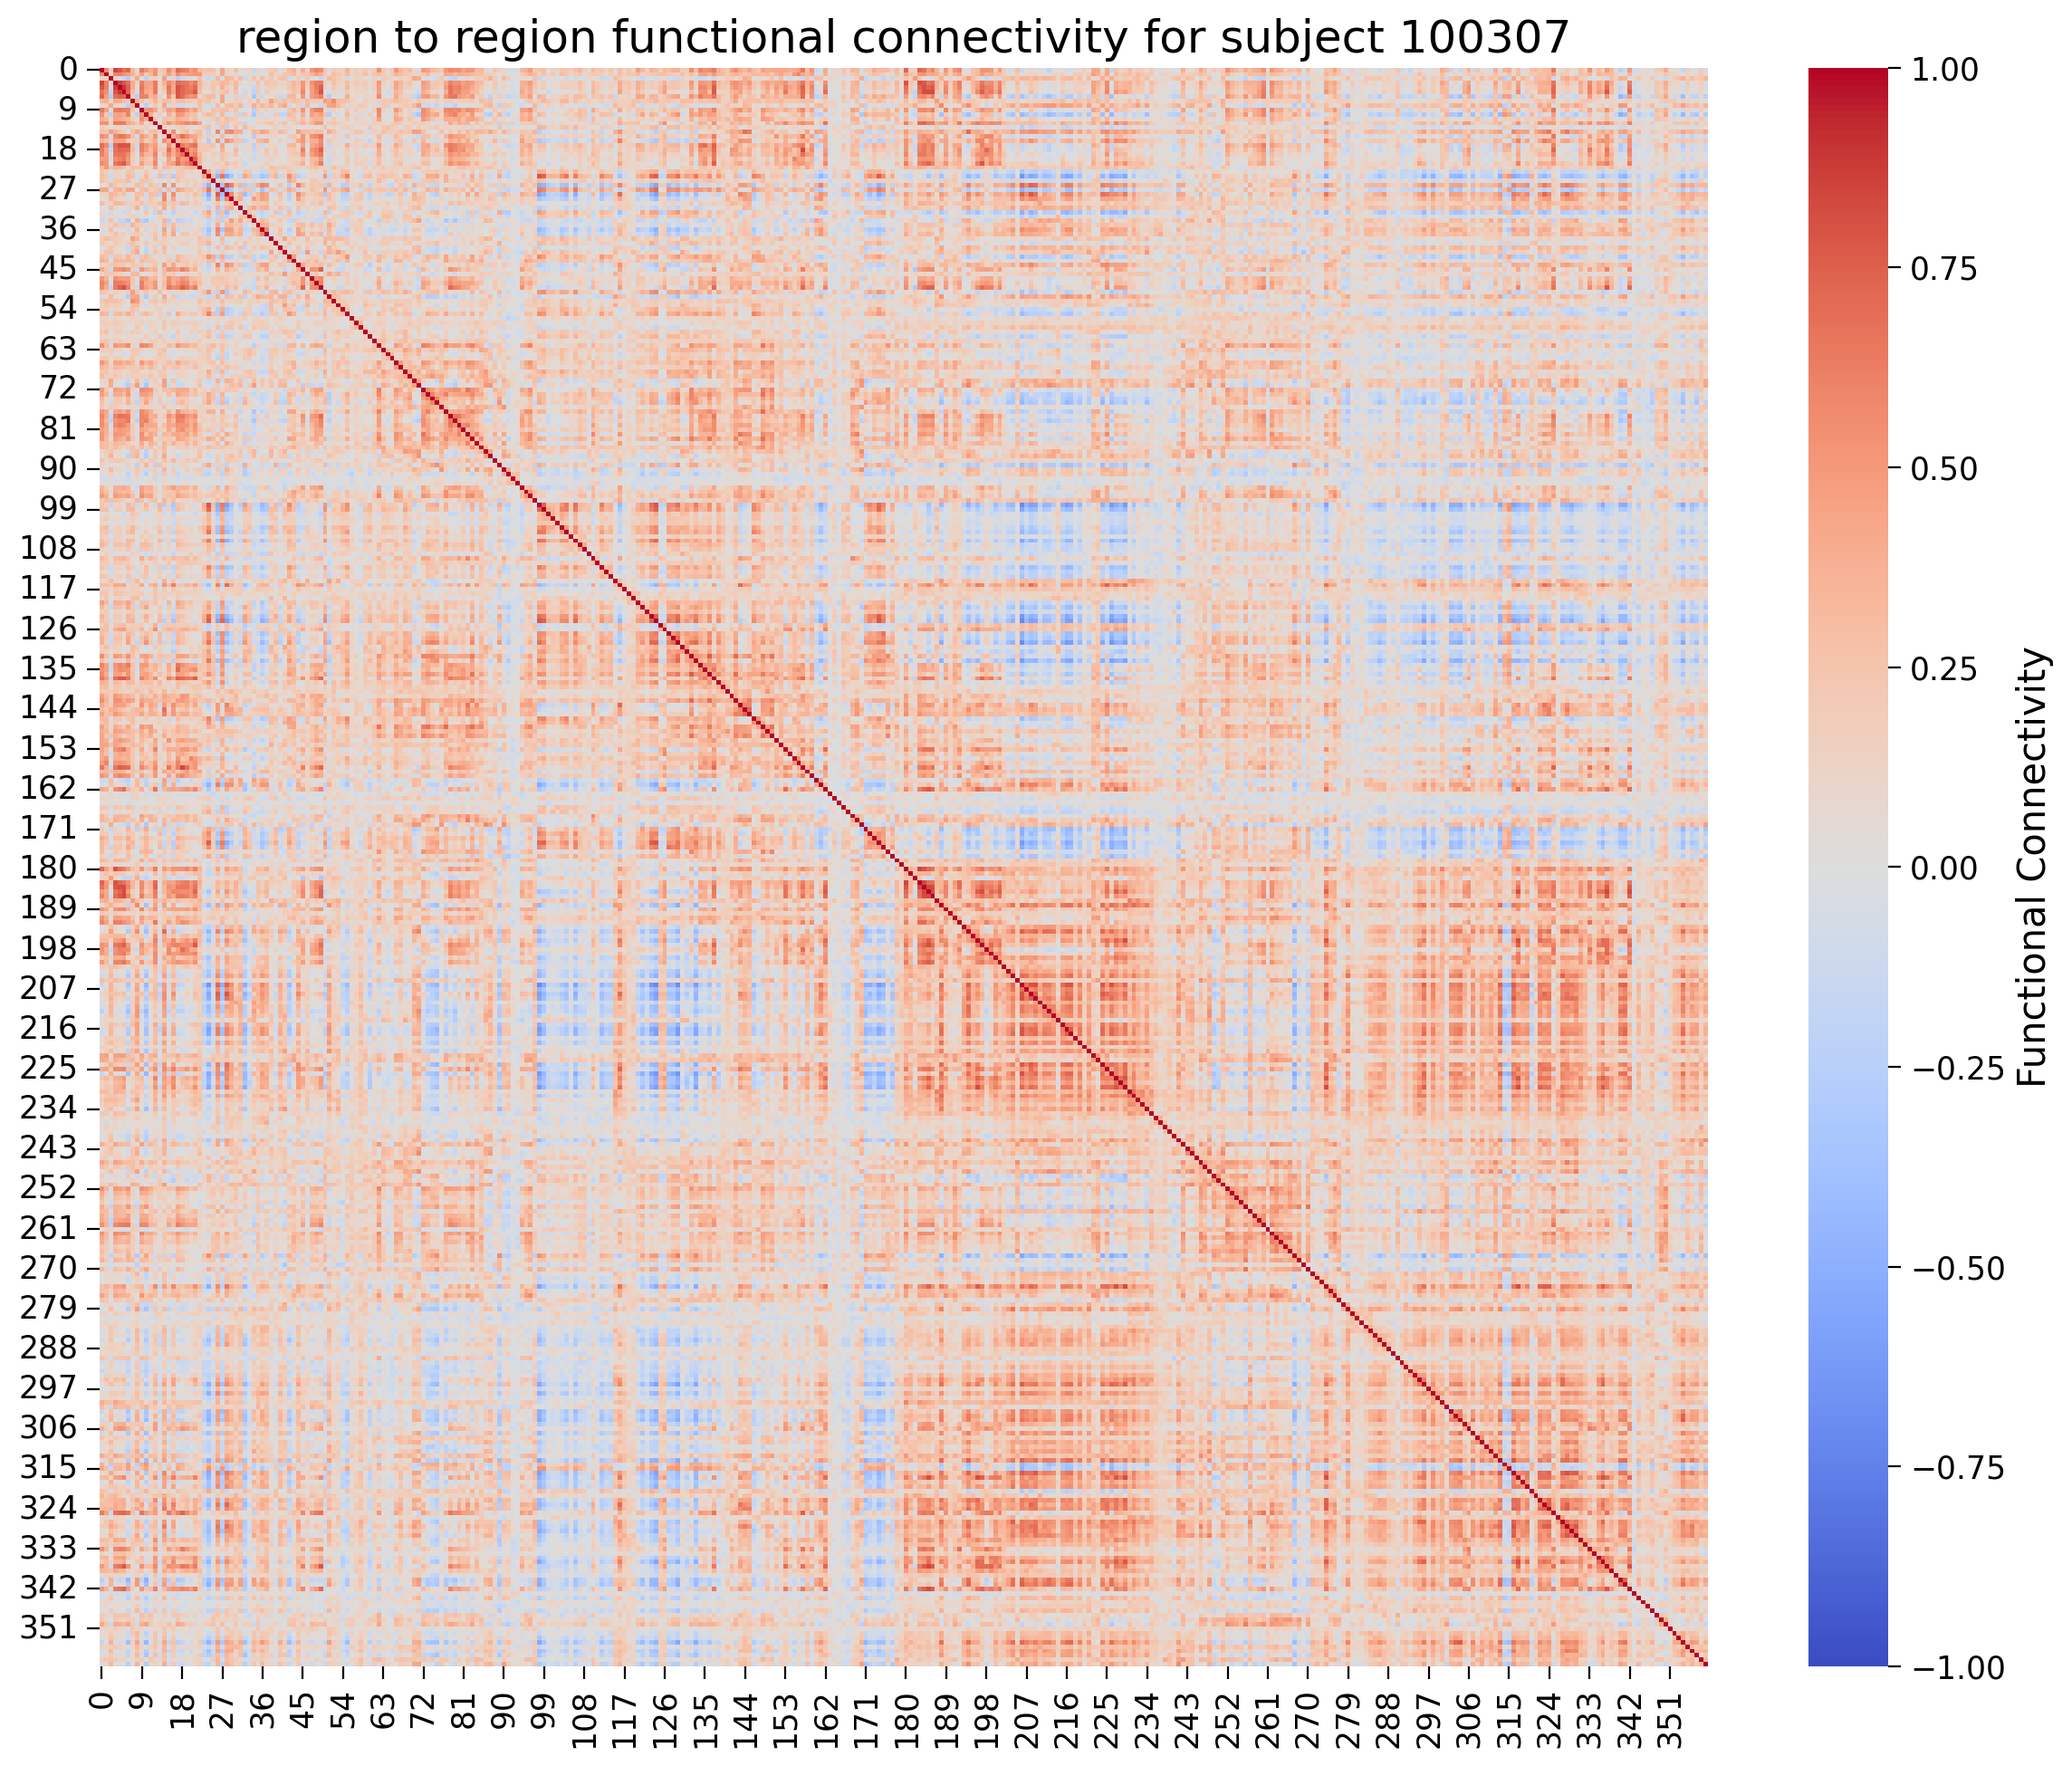

In [81]:
sub_id = subjects[0]

experiment = 'WM'

run = 0

data = load_single_timeseries(sub_id, experiment, run, remove_mean=True)


fc_matrix = np.corrcoef(data) # pearson correlation for functional connectivity for all 360 regions for subject 0


plt.figure(figsize = (12, 10))


sns.heatmap(fc_matrix, cmap='coolwarm', center=0, vmin=-1.0, vmax=1.0, cbar_kws={'label': 'Functional Connectivity'})

plt.title(f"region to region functional connectivity for subject {sub_id}")

plt.show()


# **Pre analysis**

Graph theory

Triple Network model

used jamie's code for injection

Lib import

In [98]:
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

graph

In [99]:
def connect_dots(brain_waves):
    return np.corrcoef(brain_waves)


In [100]:
def read_performance(data_cave, person, run_num):
    runs = ["LR", "RL"]
    stats_file = data_cave / "subjects" / person / "WM" / f"tfMRI_WM_{runs[run_num]}" / "EVs" / "Stats.txt"
    info = {}
    with open(stats_file) as f:
        for line in f:
            if ":" in line:
                k, v = line.rsplit(":", 1)
                try:
                    info[k.strip()] = float(v)
                except ValueError:
                    pass
    return info

In [101]:
def get_resilience(data_cave, person):
    runs_data = []
    for r in [0, 1]:
        try:
            runs_data.append(read_performance(data_cave, person, r))
        except Exception:
            pass
    if not runs_data:
        raise ValueError()
    categories = ["BP", "Faces", "Places", "Tools"]
    acc_2bk_vals = []
    for data in runs_data:
        for cat in categories:
            acc_2bk_vals.append(data[f"2-Back {cat} Median ACC"])
    return np.mean(acc_2bk_vals)


In [102]:
def get_task_frames(data_cave, person, run_num, difficulty, delay=4.0):
    runs = ["LR", "RL"]
    conditions = ["0bk_body", "0bk_faces", "0bk_places", "0bk_tools"] if difficulty == "0back" else ["2bk_body", "2bk_faces", "2bk_places", "2bk_tools"]
    frames = []
    tr = 0.72
    for cond in conditions:
        file_path = data_cave / "subjects" / person / "WM" / f"tfMRI_WM_{runs[run_num]}" / "EVs" / f"{cond}.txt"
        try:
            ev = np.loadtxt(file_path, ndmin=2)
            for onset, duration, _ in ev:
                start = int(np.floor((onset + delay) / tr))
                n_frames = int(np.ceil(duration / tr))
                frames.append(np.arange(start, start + n_frames))
        except Exception:
            pass
    if not frames:
        return np.array([], dtype=int)
    return np.unique(np.concatenate(frames))


In [103]:
def get_condition_signals(data_cave, person, difficulty, delay=4.0):
    runs = ["LR", "RL"]
    mats = []
    for r in [0, 1]:
        file_path = data_cave / "subjects" / person / "WM" / f"tfMRI_WM_{runs[r]}" / "data.npy"
        ts = np.load(file_path)
        ts = ts - ts.mean(axis=1, keepdims=True)
        frames = get_task_frames(data_cave, person, r, difficulty, delay)
        frames = frames[frames < ts.shape[1]]
        if len(frames) > 0:
            mats.append(ts[:, frames])
    if not mats:
        raise ValueError()
    return np.concatenate(mats, axis=1)

In [104]:
def get_brain_profile(brain_shift, network_names, societies):
    fingerprint = []
    for i, group_a in enumerate(societies):
        indices_a = np.where(network_names == group_a)[0]
        for group_b in societies[i:]:
            indices_b = np.where(network_names == group_b)[0]
            if len(indices_a) == 0 or len(indices_b) == 0:
                fingerprint.append(0.0)
                continue
            if group_a == group_b:
                sub = brain_shift[np.ix_(indices_a, indices_a)]
                n = sub.shape[0]
                if n > 1:
                    val = sub[np.triu_indices(n, k=1)].mean()
                else:
                    val = 0.0
            else:
                val = brain_shift[np.ix_(indices_a, indices_b)].mean()
            fingerprint.append(val)
    return fingerprint


In [105]:
def measure_all_chemistry(data_cave, people):
    regions = np.load(data_cave / "regions.npy").T
    network_names = regions[1]
    societies = np.unique(network_names)
    all_fingerprints = []
    all_scores = []
    for person in people:
        try:
            calm_mind = get_condition_signals(data_cave, person, "0back")
            busy_mind = get_condition_signals(data_cave, person, "2back")
            calm_net = connect_dots(calm_mind)
            busy_net = connect_dots(busy_mind)
            brain_shift = busy_net - calm_net
            fingerprint = get_brain_profile(brain_shift, network_names, societies)
            resilience = get_resilience(data_cave, person)
            all_fingerprints.append(fingerprint)
            all_scores.append(resilience)
        except Exception:
            continue
    return np.array(all_fingerprints), np.array(all_scores)


In [108]:
def predict_the_future(data_cave):
    subjects_file = data_cave / "subjects_list.txt"
    people = np.loadtxt(subjects_file, dtype="str").tolist()
    X, y = measure_all_chemistry(data_cave, people)
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    predictions = np.zeros_like(y)
    for train_idx, test_idx in cv.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        crystal_ball = RidgeCV(alphas=np.logspace(-3, 5, 100))
        crystal_ball.fit(X_train_scaled, y_train)
        predictions[test_idx] = crystal_ball.predict(X_test_scaled)
    r, p = pearsonr(predictions, y)
    r2 = r2_score(y, predictions)
    print(f"data size analyzed: {len(X)}")
    print(f"prediction vs actual correlation (r): {r:.4f}")
    print(f"p-value (p): {p:.4f}")
    print(f"r^2 (R2): {r2:.4f}")
    print(f"pred successful: {p < 0.05}")


it was bothering with the paths hence used pathlib :P

In [109]:
data_cave = Path.cwd().resolve() / "data" / "hcp_task"
if not data_cave.exists():
    data_cave = Path("./hcp_task")
if data_cave.exists():
    predict_the_future(data_cave)
else:
    print(f"Data cave not found at {data_cave.absolute()}")

data size analyzed: 100
prediction vs actual correlation (r): -0.0150
p-value (p): 0.8819
r^2 (R2): -0.0353
pred successful: False


Triple Network model

In [110]:
def read_performance(data_cave, person, run_num):
    runs = ["LR", "RL"]
    stats_file = data_cave / "subjects" / person / "WM" / f"tfMRI_WM_{runs[run_num]}" / "EVs" / "Stats.txt"
    info = {}
    with open(stats_file) as f:
        for line in f:
            if ":" in line:
                k, v = line.rsplit(":", 1)
                try:
                    info[k.strip()] = float(v)
                except ValueError:
                    pass
    return info

In [111]:
def get_resilience(data_cave, person):
    runs_data = []
    for r in [0, 1]:
        try:
            runs_data.append(read_performance(data_cave, person, r))
        except Exception as e:
            print(f"Error in {person}: {e}")
            pass
    if not runs_data:
        raise ValueError()
    categories = ["BP", "Faces", "Places", "Tools"]
    acc_2bk_vals = []
    for data in runs_data:
        for cat in categories:
            acc_2bk_vals.append(data[f"2-Back {cat} Median ACC"])
    return np.mean(acc_2bk_vals)

In [112]:
def get_task_frames(data_cave, person, run_num, difficulty, delay=4.0):
    runs = ["LR", "RL"]
    conditions = ["0bk_body", "0bk_faces", "0bk_places", "0bk_tools"] if difficulty == "0back" else ["2bk_body", "2bk_faces", "2bk_places", "2bk_tools"]
    frames = []
    tr = 0.72
    for cond in conditions:
        file_path = data_cave / "subjects" / person / "WM" / f"tfMRI_WM_{runs[run_num]}" / "EVs" / f"{cond}.txt"
        try:
            ev = np.loadtxt(file_path, ndmin=2)
            for onset, duration, _ in ev:
                start = int(np.floor((onset + delay) / tr))
                n_frames = int(np.ceil(duration / tr))
                frames.append(np.arange(start, start + n_frames))
        except Exception:
            pass
    if not frames:
        return np.array([], dtype=int)
    return np.unique(np.concatenate(frames))

In [95]:
def get_condition_signals(data_cave, person, difficulty, delay=4.0):
    runs = ["LR", "RL"]
    mats = []
    for r in [0, 1]:
        file_path = data_cave / "subjects" / person / "WM" / f"tfMRI_WM_{runs[r]}" / "data.npy"
        ts = np.load(file_path)
        ts = ts - ts.mean(axis=1, keepdims=True)
        frames = get_task_frames(data_cave, person, r, difficulty, delay)
        frames = frames[frames < ts.shape[1]]
        if len(frames) > 0:
            mats.append(ts[:, frames])
    if not mats:
        raise ValueError()
    return np.concatenate(mats, axis=1)


In [96]:
def run_triple_network_check(data_cave):
    subjects_file = data_cave / "subjects_list.txt"
    people = np.loadtxt(subjects_file, dtype="str").tolist()

    regions = np.load(data_cave / "regions.npy").T
    network_names = regions[1]

    salience_idx = np.where(network_names == "Cingulo-Oper")[0]
    fpn_idx = np.where(network_names == "Frontopariet")[0]
    dmn_idx = np.where(network_names == "Default")[0]

    salience_acts = []
    fpn_acts = []
    dmn_deacts = []
    switching_effs = []
    accs = []

    for person in people:
        try:
            calm_mind = get_condition_signals(data_cave, person, "0back")
            busy_mind = get_condition_signals(data_cave, person, "2back")

            contrast = busy_mind.mean(axis=1) - calm_mind.mean(axis=1)

            salience_val = contrast[salience_idx].mean()
            fpn_val = contrast[fpn_idx].mean()
            dmn_val = -contrast[dmn_idx].mean()

            switching_val = fpn_val + dmn_val
            score = get_resilience(data_cave, person)

            salience_acts.append(salience_val)
            fpn_acts.append(fpn_val)
            dmn_deacts.append(dmn_val)
            switching_effs.append(switching_val)
            accs.append(score)
        except Exception as e:
            print(f"Error in {person}: {e}")
            continue

    salience_acts = np.array(salience_acts)
    fpn_acts = np.array(fpn_acts)
    dmn_deacts = np.array(dmn_deacts)
    switching_effs = np.array(switching_effs)
    accs = np.array(accs)

    print(f"subjects analyzed: {len(accs)}")

    r_fpn, p_fpn = pearsonr(salience_acts, fpn_acts)
    print(f"saleince -> fpn activation correlation: r = {r_fpn:.4f}, p = {p_fpn:.4f}")

    r_dmn, p_dmn = pearsonr(salience_acts, dmn_deacts)
    print(f"saleince -> dmn suppression correlation: r = {r_dmn:.4f}, p = {p_dmn:.4f}")

    r_perf, p_perf = pearsonr(switching_effs, accs)
    print(f"effiency : r = {r_perf:.4f}, p = {p_perf:.4f}")

    X = np.column_stack([salience_acts, switching_effs])
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    pred = np.zeros_like(accs)

    for train_idx, test_idx in cv.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = accs[train_idx], accs[test_idx]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        crystal_ball = LinearRegression()
        crystal_ball.fit(X_train_scaled, y_train)
        pred[test_idx] = crystal_ball.predict(X_test_scaled)

    r_cv, p_cv = pearsonr(pred, accs)
    r2_cv = r2_score(accs, pred)
    print(f"pred correlation (r): {r_cv:.4f}")
    print(f"pred p-value (p): {p_cv:.4f}")
    print(f"pred R2: {r2_cv:.4f}")

In [113]:
data_cave = Path.cwd().resolve() / "data" / "hcp_task"
if not data_cave.exists():
    data_cave = Path("./hcp_task")
if data_cave.exists():
    run_triple_network_check(data_cave)
else:
    print(f"Data cave not found at {data_cave.absolute()}")


subjects analyzed: 100
saleince -> fpn activation correlation: r = 0.7547, p = 0.0000
saleince -> dmn suppression correlation: r = -0.8197, p = 0.0000
effiency : r = 0.1830, p = 0.0684
pred correlation (r): 0.0760
pred p-value (p): 0.4524
pred R2: -0.0080
